# GameTheory-17 : Apprentissage par Renforcement Multi-Agent

**Navigation** : [<< 16-MechanismDesign](GameTheory-16-MechanismDesign.ipynb) | [Index](README.md)

## Self-Play, NFSP et PSRO

Ce notebook explore l'intersection entre la theorie des jeux et l'apprentissage par renforcement (RL) dans les environnements multi-agents.

### Objectifs d'apprentissage

- Comprendre les defis specifiques du MARL (Multi-Agent RL)
- Maitriser le concept de self-play et ses variantes
- Implementer Fictitious Play et ses extensions neurales (NFSP)
- Decouvrir PSRO (Policy-Space Response Oracles)

### Prerequis

- Notebooks 1-14, notions de base en RL

### Duree estimee : 55 minutes

---

## 1. Defis du Multi-Agent RL

### 1.1 Pourquoi le MARL est difficile

| Defi | Description |
|------|-------------|
| **Non-stationnarite** | L'environnement change car les autres agents apprennent |
| **Credit assignment** | Difficult de savoir qui est responsable du resultat |
| **Espace d'action conjoint** | Explose exponentiellement avec le nombre d'agents |
| **Equilibres multiples** | Plusieurs Nash possibles, convergence incertaine |
| **Exploration** | Coordination implicite necessaire |

### 1.2 Approches principales

1. **Independent Learning** : chaque agent apprend comme si les autres etaient statiques
2. **Self-Play** : l'agent joue contre des versions de lui-meme
3. **Population-based Training** : ensemble d'agents qui co-evoluent
4. **Centralized Training, Decentralized Execution** (CTDE)

### 1.3 Objectifs d'apprentissage

- **Jeux a somme nulle** : trouver un equilibre de Nash
- **Jeux cooperatifs** : maximiser le gain collectif
- **Jeux generaux** : trouver un equilibre stable

In [1]:
# Installation des dependances
import subprocess
import sys

packages = ['numpy', 'matplotlib', 'tqdm']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

# Tentative OpenSpiel
try:
    import pyspiel
    OPENSPIEL_AVAILABLE = True
except ImportError:
    try:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'open_spiel'])
        import pyspiel
        OPENSPIEL_AVAILABLE = True
    except:
        OPENSPIEL_AVAILABLE = False
        print("OpenSpiel non disponible - utilisation des implementations locales")

import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Optional, Callable
from collections import defaultdict
from dataclasses import dataclass
from abc import ABC, abstractmethod
from tqdm import tqdm

print("Imports reussis")
print(f"OpenSpiel disponible: {OPENSPIEL_AVAILABLE}")

Imports reussis
OpenSpiel disponible: True


### Interpretation : Environnement experimentale

Le code ci-dessus prepare l'environnement pour les experiences :

| Composant | Usage |
|-----------|-------|
| **OpenSpiel** | Bibliotheque de jeux et algorithmes MARL (DeepMind) |
| **NumPy** | Calculs numeriques pour les operations matricielles |
| **Matplotlib** | Visualisation des courbes de convergence |
| **TQDM** | Barres de progression pour les longs entrainements |

La verification de la disponibilite d'OpenSpiel permet au notebook de fonctionner meme si la bibliotheque n'est pas installee, en utilisant des implementations locales de secours.

## 2. Self-Play : Apprentissage par Auto-Competition

### 2.1 Principe

Au lieu d'avoir un adversaire fixe, l'agent joue contre :
- Lui-meme (self-play naif)
- Des versions anterieures (historical self-play)
- Un melange (fictitious self-play)

### 2.2 Problemes du self-play naif

- **Forgetting catastrophique** : oublie comment battre les anciennes strategies
- **Cycles** : oscillations entre strategies non-transitives (RPS)
- **Exploitation locale** : sur-optimise contre la version courante

### 2.3 AlphaGo/AlphaZero

Succes spectaculaire du self-play avec MCTS + reseaux de neurones dans les jeux a information parfaite.

### Transition : Du probleme a la solution

Maintenant que nous avons identifie les defis du MARL, nous allons explorer les algorithmes qui ont ete developpes pour les surmonter. Nous commencerons par le plus simple : **self-play**.

L'idee du self-play est intuitive : si un agent peut se battre lui-meme, il deviendra plus fort. Mais comme nous allons le voir, cette approche naive a des limitations importantes qui ont motive le developpement d'algorithmes plus sophistiques.

In [2]:
class MatrixGame:
    """Jeu matriciel a 2 joueurs."""
    
    def __init__(self, payoff_matrix_p1: np.ndarray, name: str = "Game"):
        """
        payoff_matrix_p1[i, j] = payoff de P1 si P1 joue i et P2 joue j.
        Jeu a somme nulle : payoff P2 = -payoff P1.
        """
        self.A = payoff_matrix_p1
        self.name = name
        self.n_actions_p1 = self.A.shape[0]
        self.n_actions_p2 = self.A.shape[1]
    
    def get_payoff(self, action_p1: int, action_p2: int) -> Tuple[float, float]:
        """Retourne (payoff P1, payoff P2)."""
        p1 = self.A[action_p1, action_p2]
        return (p1, -p1)
    
    def expected_payoff(self, strategy_p1: np.ndarray, 
                        strategy_p2: np.ndarray) -> Tuple[float, float]:
        """Payoff espere pour des strategies mixtes."""
        p1 = strategy_p1 @ self.A @ strategy_p2
        return (p1, -p1)
    
    def best_response(self, opponent_strategy: np.ndarray, 
                      player: int) -> np.ndarray:
        """Meilleure reponse pure a une strategie mixte adverse."""
        if player == 0:  # P1
            payoffs = self.A @ opponent_strategy
            best_action = np.argmax(payoffs)
            br = np.zeros(self.n_actions_p1)
            br[best_action] = 1.0
        else:  # P2 (minimise payoff P1)
            payoffs = self.A.T @ opponent_strategy
            best_action = np.argmin(payoffs)  # Min car somme nulle
            br = np.zeros(self.n_actions_p2)
            br[best_action] = 1.0
        return br
    
    def exploitability(self, strategy_p1: np.ndarray, 
                       strategy_p2: np.ndarray) -> float:
        """
        Mesure de la distance a l'equilibre de Nash.
        
        = gain max de P1 en deviant + gain max de P2 en deviant
        """
        # Meilleure reponse de P1
        br_p1 = self.best_response(strategy_p2, 0)
        gain_p1 = self.expected_payoff(br_p1, strategy_p2)[0] - \
                  self.expected_payoff(strategy_p1, strategy_p2)[0]
        
        # Meilleure reponse de P2
        br_p2 = self.best_response(strategy_p1, 1)
        gain_p2 = self.expected_payoff(strategy_p1, br_p2)[1] - \
                  self.expected_payoff(strategy_p1, strategy_p2)[1]
        
        return gain_p1 + gain_p2


# Jeux classiques
def create_rps() -> MatrixGame:
    """Rock-Paper-Scissors."""
    A = np.array([
        [0, -1, 1],   # Rock
        [1, 0, -1],   # Paper
        [-1, 1, 0]    # Scissors
    ])
    return MatrixGame(A, "Rock-Paper-Scissors")


def create_matching_pennies() -> MatrixGame:
    """Matching Pennies."""
    A = np.array([
        [1, -1],   # Heads
        [-1, 1]    # Tails
    ])
    return MatrixGame(A, "Matching Pennies")


# Test
rps = create_rps()
print(f"Jeu: {rps.name}")
print(f"Matrice de gains P1:")
print(rps.A)

# Equilibre de Nash = (1/3, 1/3, 1/3)
nash = np.array([1/3, 1/3, 1/3])
print(f"\nExploitabilite a Nash: {rps.exploitability(nash, nash):.6f}")

Jeu: Rock-Paper-Scissors
Matrice de gains P1:
[[ 0 -1  1]
 [ 1  0 -1]
 [-1  1  0]]

Exploitabilite a Nash: 0.000000


### Implementation : Jeux matriciels

Pour experimenter avec ces algorithmes, nous allons implementer des jeux matriciels a 2 joueurs. La classe `MatrixGame` fournit :

| Methode | Description |
|---------|-------------|
| `get_payoff()` | Retourne les gains pour une paire d'actions pures |
| `expected_payoff()` | Calcule le gain espere pour des strategies mixtes |
| `best_response()` | Trouve la meilleure reponse pure a une strategie adverse |
| `exploitability()` | Mesure la distance a l'equilibre de Nash |

**Rock-Paper-Scissors** servira de jeu de test : son equilibre de Nash est la strategie uniforme (1/3, 1/3, 1/3), et l'exploitabilite doit converger vers 0.

### Interpretation : Jeux matriciels et exploitabilite

Le code ci-dessus definit les concepts fondamentaux pour les jeux a somme nulle :

| Concept | Implementation | Signification |
|---------|----------------|---------------|
| **Jeu matriciel** | `MatrixGame` | Representation compacte d'un jeu a 2 joueurs |
| **Meilleure reponse** | `best_response()` | Strategie optimale contre une strategie adverse fixee |
| **Exploitabilite** | `exploitability()` | Distance a l'equilibre de Nash |

**Rock-Paper-Scissors (RPS)** est l'exemple canonique de jeu a somme nulle avec equilibre mixte :
- Pas de strategie pure dominante
- Equilibre de Nash unique : (1/3, 1/3, 1/3) pour chaque joueur
- Exploitabilite = 0 confirme que cette strategie est un equilibre

> **Note technique** : L'exploitabilite mesure la somme des gains possibles si chaque joueur deviait unilateralement vers sa meilleure reponse. A l'equilibre de Nash, aucune deviation n'est profitable, donc l'exploitabilite est nulle.

Self-Play Naif sur Rock-Paper-Scissors

Strategie finale P1: [0.40460089 0.39714467 0.19825444]
Strategie finale P2: [0.40460089 0.39714467 0.19825444]
Exploitabilite finale: 0.4127


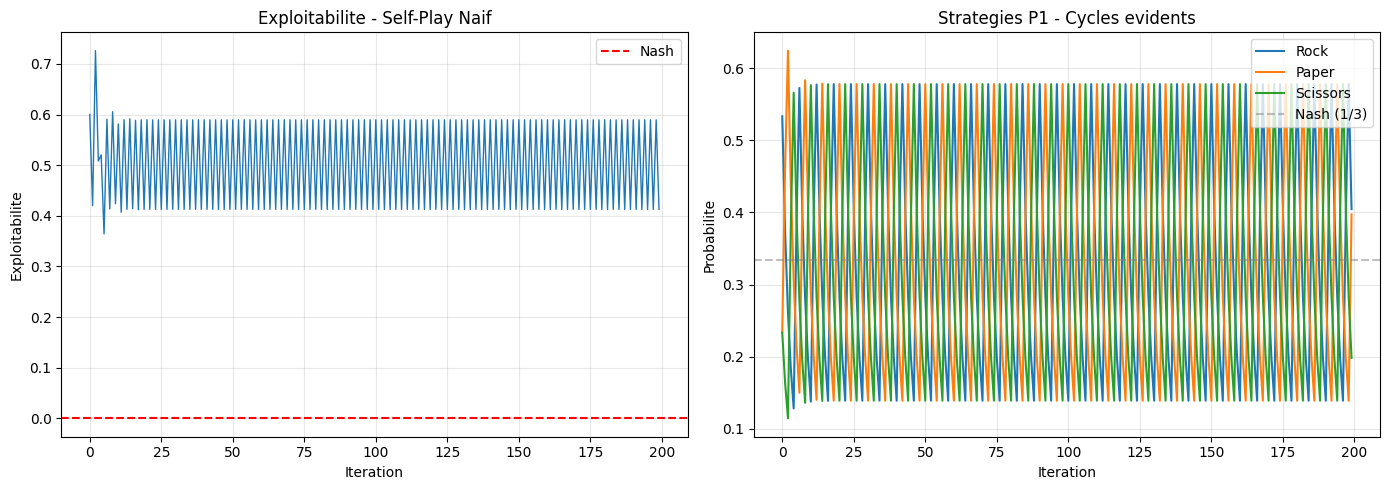


-> Le self-play naif oscille sans converger vers Nash!


In [3]:
class NaiveSelfPlay:
    """
    Self-play naif : chaque joueur optimise contre la strategie
    courante de l'adversaire.
    """
    
    def __init__(self, game: MatrixGame, learning_rate: float = 0.1):
        self.game = game
        self.lr = learning_rate
        
        # Strategies initiales uniformes
        self.strategy_p1 = np.ones(game.n_actions_p1) / game.n_actions_p1
        self.strategy_p2 = np.ones(game.n_actions_p2) / game.n_actions_p2
        
        self.history = {
            'exploitability': [],
            'strategy_p1': [],
            'strategy_p2': []
        }
    
    def step(self):
        """Une iteration de self-play naif."""
        # Meilleure reponse de chaque joueur
        br_p1 = self.game.best_response(self.strategy_p2, 0)
        br_p2 = self.game.best_response(self.strategy_p1, 1)
        
        # Mise a jour graduelle (moving average)
        self.strategy_p1 = (1 - self.lr) * self.strategy_p1 + self.lr * br_p1
        self.strategy_p2 = (1 - self.lr) * self.strategy_p2 + self.lr * br_p2
        
        # Normaliser
        self.strategy_p1 /= self.strategy_p1.sum()
        self.strategy_p2 /= self.strategy_p2.sum()
        
        # Enregistrer
        self.history['exploitability'].append(
            self.game.exploitability(self.strategy_p1, self.strategy_p2)
        )
        self.history['strategy_p1'].append(self.strategy_p1.copy())
        self.history['strategy_p2'].append(self.strategy_p2.copy())
    
    def train(self, iterations: int):
        """Entraine pendant n iterations."""
        for _ in range(iterations):
            self.step()


# Demonstration : self-play naif sur RPS
print("Self-Play Naif sur Rock-Paper-Scissors")
print("="*50)

rps = create_rps()
sp_naive = NaiveSelfPlay(rps, learning_rate=0.3)
sp_naive.train(200)

print(f"\nStrategie finale P1: {sp_naive.strategy_p1}")
print(f"Strategie finale P2: {sp_naive.strategy_p2}")
print(f"Exploitabilite finale: {sp_naive.history['exploitability'][-1]:.4f}")

# Visualisation des cycles
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Exploitabilite
ax1 = axes[0]
ax1.plot(sp_naive.history['exploitability'], linewidth=1)
ax1.axhline(y=0, color='r', linestyle='--', label='Nash')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Exploitabilite')
ax1.set_title('Exploitabilite - Self-Play Naif')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Evolution des strategies
ax2 = axes[1]
strategies = np.array(sp_naive.history['strategy_p1'])
for i, label in enumerate(['Rock', 'Paper', 'Scissors']):
    ax2.plot(strategies[:, i], label=label)
ax2.axhline(y=1/3, color='gray', linestyle='--', alpha=0.5, label='Nash (1/3)')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Probabilite')
ax2.set_title('Strategies P1 - Cycles evidents')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('naive_selfplay_rps.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n-> Le self-play naif oscille sans converger vers Nash!")

## 3. Fictitious Play

### 3.1 Principe (Brown, 1951)

Chaque joueur :
1. Maintient une estimation de la strategie adverse (moyenne empirique)
2. Joue la meilleure reponse a cette estimation

### 3.2 Convergence

- Converge vers Nash dans les jeux a somme nulle
- Converge dans les jeux a 2 joueurs avec somme constante
- Peut ne pas converger dans les jeux generaux

### 3.3 Avantages

- Simple a implementer
- Garanties theoriques dans certaines classes de jeux
- Base pour des methodes plus sophistiquees (NFSP)

### Exercice : Calcul d'exploitabilite

**Objectif** : Implementer une fonction qui calcule l'exploitabilite d'un profil de strategie sur un jeu matriciel. Verifier que la strategie uniforme est la moins exploitable sur RPS et Matching Pennies.

**Contexte** : L'exploitabilite mesure a quel point un adversaire optimal peut punir votre strategie. C'est la metrique cle pour evaluer les algorithmes MARL.

- **Indice :** L'exploitabilite = somme des gains de la meilleure reponse de chaque joueur contre la strategie de l'autre.
- **Etape 1 :** Calculer la meilleure reponse de chaque joueur contre la strategie adverse.
- **Etape 2 :** Sommer les gains esperes des meilleures reponses.
- **Etape 3 :** Verifier que la strategie uniforme a la plus faible exploitabilite.

In [4]:
def exercice_compute_exploitability(game, strat_p1: np.ndarray, strat_p2: np.ndarray) -> dict:
    """
    Calcule l'exploitabilite d'un profil de strategie.
    
    Args:
        game: un objet MatrixGame (avec .payoff_matrix_p1, .payoff_matrix_p2)
        strat_p1: strategie du joueur 1
        strat_p2: strategie du joueur 2
    
    Returns:
        dict avec :
            'exploitability': valeur d'exploitabilite totale
            'br_p1': meilleure reponse du joueur 1
            'br_p2': meilleure reponse du joueur 2
    """
    return {"exploitability": 0.0, "br_p1": None, "br_p2": None}  # TODO etudiant

# Test sur RPS
rps = create_rps()
uniform = np.array([1/3, 1/3, 1/3])
biased = np.array([0.5, 0.3, 0.2])

exp_uniform = exercice_compute_exploitability(rps, uniform, uniform)
exp_biased = exercice_compute_exploitability(rps, biased, biased)
print(f"RPS uniform exploitabilite: {exp_uniform['exploitability']:.4f}")
print(f"RPS biaise exploitabilite: {exp_biased['exploitability']:.4f}")
print(f"Uniforme moins exploitable ? {exp_uniform['exploitability'] <= exp_biased['exploitability']}")

print("Exercice a completer")

RPS uniform exploitabilite: 0.0000
RPS biaise exploitabilite: 0.0000
Uniforme moins exploitable ? True
Exercice a completer


### Interpretation : Pourquoi le self-play naif echoue

Les resultats du self-play naif revelent un probleme fondamental :

| Phenomene | Cause | Consequence |
|-----------|-------|-------------|
| **Cycles perpetuels** | Best response pure (Rock → Paper → Scissors → Rock) | L'exploitabilite ne converge pas vers 0 |
| **Oubli catastrophique** | Moving average privilegie les dernieres strategies | L'agent "oublie" comment battre les anciennes strategies |
| **Non-stationnarite** | L'environnement (adversaire) change a chaque iteration | Pas de convergence garantie |

**Solution : Fictitious Play**

Au lieu de reagir a la strategie courante de l'adversaire, Fictitious Play (Brown, 1951) propose de reagir a la **strategie moyenne historique**. Cela garantit la convergence dans les jeux a somme nulle.

> **Intuition** : Imaginez jouer contre un adversaire qui change de strategie. Si vous repondez toujours a sa derniere strategie, vous etes toujours en retard. Si vous repondez a sa moyenne historique, vous pouvez anticiper sa tendance generale.

Fictitious Play sur Rock-Paper-Scissors

Strategie moyenne P1: [0.32803181 0.34791252 0.32405567]
Strategie moyenne P2: [0.32803181 0.34791252 0.32405567]
Exploitabilite finale: 0.039761


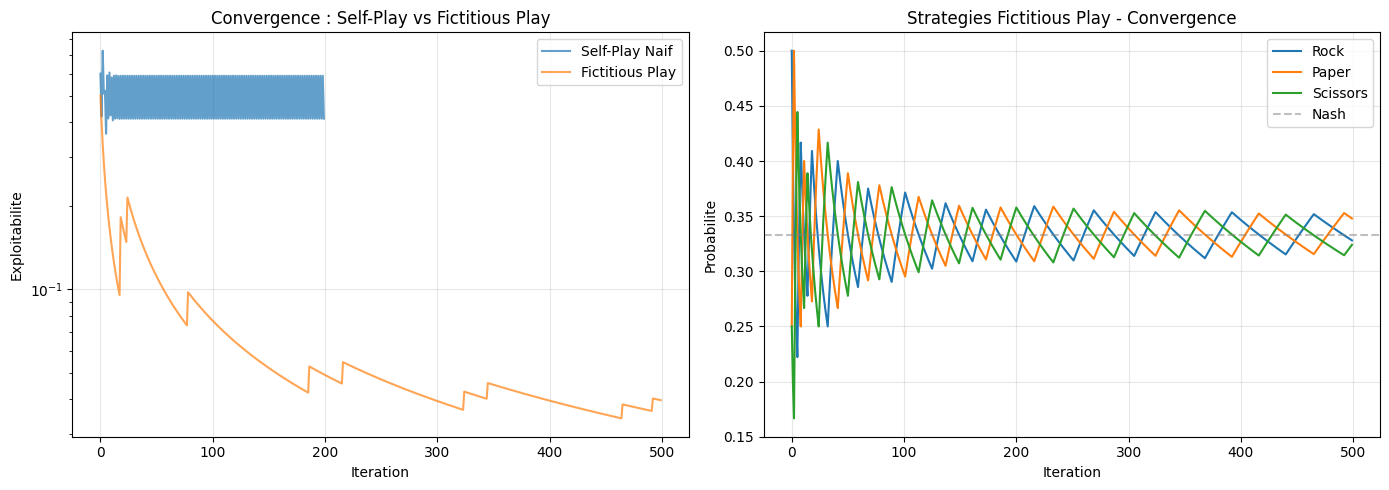


-> Fictitious Play converge vers Nash!


In [5]:
class FictitiousPlay:
    """
    Fictitious Play : joue la meilleure reponse a la
    strategie moyenne historique de l'adversaire.
    """
    
    def __init__(self, game: MatrixGame):
        self.game = game
        
        # Compteurs d'actions jouees
        self.counts_p1 = np.ones(game.n_actions_p1)  # Laplace smoothing
        self.counts_p2 = np.ones(game.n_actions_p2)
        
        self.history = {
            'exploitability': [],
            'avg_strategy_p1': [],
            'avg_strategy_p2': []
        }
    
    def get_average_strategy(self, player: int) -> np.ndarray:
        """Retourne la strategie moyenne (frequence empirique)."""
        if player == 0:
            return self.counts_p1 / self.counts_p1.sum()
        else:
            return self.counts_p2 / self.counts_p2.sum()
    
    def step(self):
        """Une iteration de Fictitious Play."""
        # Strategies moyennes adverses
        avg_p1 = self.get_average_strategy(0)
        avg_p2 = self.get_average_strategy(1)
        
        # Meilleures reponses aux moyennes
        br_p1 = self.game.best_response(avg_p2, 0)
        br_p2 = self.game.best_response(avg_p1, 1)
        
        # Action jouee = argmax de la meilleure reponse
        action_p1 = np.argmax(br_p1)
        action_p2 = np.argmax(br_p2)
        
        # Mettre a jour les compteurs
        self.counts_p1[action_p1] += 1
        self.counts_p2[action_p2] += 1
        
        # Enregistrer
        new_avg_p1 = self.get_average_strategy(0)
        new_avg_p2 = self.get_average_strategy(1)
        
        self.history['exploitability'].append(
            self.game.exploitability(new_avg_p1, new_avg_p2)
        )
        self.history['avg_strategy_p1'].append(new_avg_p1.copy())
        self.history['avg_strategy_p2'].append(new_avg_p2.copy())
    
    def train(self, iterations: int):
        for _ in range(iterations):
            self.step()


# Comparaison avec Self-Play naif
print("Fictitious Play sur Rock-Paper-Scissors")
print("="*50)

fp = FictitiousPlay(rps)
fp.train(500)

print(f"\nStrategie moyenne P1: {fp.get_average_strategy(0)}")
print(f"Strategie moyenne P2: {fp.get_average_strategy(1)}")
print(f"Exploitabilite finale: {fp.history['exploitability'][-1]:.6f}")

# Comparaison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Exploitabilite comparee
ax1 = axes[0]
ax1.plot(sp_naive.history['exploitability'][:500], label='Self-Play Naif', alpha=0.7)
ax1.plot(fp.history['exploitability'], label='Fictitious Play', alpha=0.7)
ax1.axhline(y=0, color='r', linestyle='--', alpha=0.5)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Exploitabilite')
ax1.set_title('Convergence : Self-Play vs Fictitious Play')
ax1.legend()
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# Evolution des strategies FP
ax2 = axes[1]
strategies = np.array(fp.history['avg_strategy_p1'])
for i, label in enumerate(['Rock', 'Paper', 'Scissors']):
    ax2.plot(strategies[:, i], label=label)
ax2.axhline(y=1/3, color='gray', linestyle='--', alpha=0.5, label='Nash')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Probabilite')
ax2.set_title('Strategies Fictitious Play - Convergence')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fictitious_play_rps.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n-> Fictitious Play converge vers Nash!")

## 4. Neural Fictitious Self-Play (NFSP)

### 4.1 Motivation (Heinrich & Silver, 2016)

Fictitious Play necessite de stocker tout l'historique. NFSP utilise des reseaux de neurones pour :
1. **Approximer la meilleure reponse** (RL network)
2. **Approximer la strategie moyenne** (Supervised Learning network)

### 4.2 Architecture

```
+-------------------+     +-------------------+
|   RL Network      |     |   SL Network      |
|   (Best Response) |     |   (Avg Strategy)  |
+--------+----------+     +--------+----------+
         |                         |
         v                         v
    Q(s, a)                    pi(a|s)
         |                         |
         +------------+------------+
                      |
                      v
              epsilon-greedy:
              eta * pi + (1-eta) * BR(Q)
```

### 4.3 Resultats

- Premier algorithme RL a approximer l'equilibre de Nash au Heads-Up Limit Hold'em
- Base pour des approches plus avancees

### Schema : l'architecture NFSP

Le diagramme reprend la combinaison decrite ci-dessus : le RL Network (meilleure reponse) et le SL Network (strategie moyenne) produisent respectivement Q(s,a) et pi(a|s), agreges par la politique epsilon-greedy.

```mermaid
flowchart TD
    RL["RL Network (Best Response)"] --> Q["Q(s, a)"]
    SL["SL Network (Avg Strategy)"] --> PI["pi(a|s)"]
    Q --> EG["epsilon-greedy: eta * pi + (1 - eta) * BR(Q)"]
    PI --> EG
```

### Exercice : Convergence du Fictitious Play

**Objectif** : Executer le Fictitious Play sur Matching Pennies pendant N iterations et verifier que la strategie moyenne converge vers (0.5, 0.5).

**Contexte** : Le Fictitious Play est un algorithme ou chaque joueur joue la meilleure reponse a la frequence empirique des coups adverses. Sur les jeux a somme nulle, il converge vers Nash.

- **Indice :** Utiliser la classe FictitiousPlay definie ci-dessus.
- **Etape 1 :** Creer un jeu Matching Pennies avec create_matching_pennies().
- **Etape 2 :** Entrainer le FictitiousPlay pendant 1000 iterations.
- **Etape 3 :** Verifier que get_average_strategy() est proche de (0.5, 0.5).

In [6]:
def exercice_fictitious_play_convergence(iterations: int = 1000) -> dict:
    """
    Fictitious Play sur Matching Pennies.
    
    Args:
        iterations: nombre d'iterations
    
    Returns:
        dict avec :
            'avg_p1': strategie moyenne du joueur 1
            'avg_p2': strategie moyenne du joueur 2
            'converged': True si proche de (0.5, 0.5)
            'error_p1': distance L2 a (0.5, 0.5)
    """
    return {"avg_p1": None, "avg_p2": None, "converged": False, "error_p1": 0.0}  # TODO etudiant

result_fp = exercice_fictitious_play_convergence(1000)
print(f"Strategie P1: {result_fp['avg_p1']}")
print(f"Strategie P2: {result_fp['avg_p2']}")
print(f"Converge: {result_fp['converged']}")
print(f"Erreur: {result_fp['error_p1']:.4f}")

print("Exercice a completer")

Strategie P1: None
Strategie P2: None
Converge: False
Erreur: 0.0000
Exercice a completer


### Transition : Vers les approches neurales

Fictitious Play converge bien mais a une limitation majeure : il necessite de stocker tout l'historique des actions pour calculer la strategie moyenne empirique. Dans les jeux complexes :
- **Espace d'actions enorme** (ex: poker avec 10^15 situations)
- **Historique infini** impossible a stocker
- **Generalisation** necessaire entre situations similaires

**NFSP (Neural Fictitious Self-Play)** résout ce probleme en utilisant des reseaux de neurones :
1. **Reseau RL** : apprend la meilleure reponse (Q-values)
2. **Reseau SL** : approxime la strategie moyenne historique
3. **Echantillonnage** : reservoir sampling pour maintenir un buffer representatif

Cette approche a permis a DeepMind de battre des champions de poker en 2019.

In [7]:
class SimplifiedNFSP:
    """
    Version simplifiee de NFSP pour jeux matriciels.
    
    Utilise des tables au lieu de reseaux de neurones.
    """
    
    def __init__(self, game: MatrixGame, 
                 eta: float = 0.1,        # Prob d'utiliser avg strategy
                 rl_lr: float = 0.01,     # Learning rate RL
                 sl_lr: float = 0.01):    # Learning rate SL
        self.game = game
        self.eta = eta
        self.rl_lr = rl_lr
        self.sl_lr = sl_lr
        
        # Q-values pour best response (RL)
        self.Q_p1 = np.zeros(game.n_actions_p1)
        self.Q_p2 = np.zeros(game.n_actions_p2)
        
        # Strategie moyenne (SL)
        self.avg_strategy_p1 = np.ones(game.n_actions_p1) / game.n_actions_p1
        self.avg_strategy_p2 = np.ones(game.n_actions_p2) / game.n_actions_p2
        
        self.history = {
            'exploitability': [],
            'avg_strategy_p1': [],
            'avg_strategy_p2': []
        }
    
    def get_action_p1(self, use_avg: bool) -> int:
        """Selectionne une action pour P1."""
        if use_avg:
            return np.random.choice(self.game.n_actions_p1, p=self.avg_strategy_p1)
        else:
            return np.argmax(self.Q_p1)  # Best response
    
    def get_action_p2(self, use_avg: bool) -> int:
        """Selectionne une action pour P2."""
        if use_avg:
            return np.random.choice(self.game.n_actions_p2, p=self.avg_strategy_p2)
        else:
            return np.argmin(self.Q_p2)  # Min car P2 minimise
    
    def step(self):
        """Une iteration de NFSP."""
        # Decider si on utilise avg strategy ou best response
        use_avg_p1 = np.random.random() < self.eta
        use_avg_p2 = np.random.random() < self.eta
        
        # Jouer
        action_p1 = self.get_action_p1(use_avg_p1)
        action_p2 = self.get_action_p2(use_avg_p2)
        
        # Obtenir les payoffs
        payoff_p1, payoff_p2 = self.game.get_payoff(action_p1, action_p2)
        
        # Mise a jour Q-values (RL - contre la strategie moyenne adverse)
        # Pour P1 : Q[a] = E[payoff | a, opponent plays avg]
        expected_payoffs_p1 = self.game.A @ self.avg_strategy_p2
        self.Q_p1 = (1 - self.rl_lr) * self.Q_p1 + self.rl_lr * expected_payoffs_p1
        
        expected_payoffs_p2 = -self.game.A.T @ self.avg_strategy_p1  # Negatif car somme nulle
        self.Q_p2 = (1 - self.rl_lr) * self.Q_p2 + self.rl_lr * expected_payoffs_p2
        
        # Mise a jour strategie moyenne (SL - supervised vers best response)
        br_p1 = np.zeros(self.game.n_actions_p1)
        br_p1[np.argmax(self.Q_p1)] = 1.0
        self.avg_strategy_p1 = (1 - self.sl_lr) * self.avg_strategy_p1 + self.sl_lr * br_p1
        self.avg_strategy_p1 /= self.avg_strategy_p1.sum()
        
        br_p2 = np.zeros(self.game.n_actions_p2)
        br_p2[np.argmin(self.Q_p2)] = 1.0
        self.avg_strategy_p2 = (1 - self.sl_lr) * self.avg_strategy_p2 + self.sl_lr * br_p2
        self.avg_strategy_p2 /= self.avg_strategy_p2.sum()
        
        # Enregistrer
        self.history['exploitability'].append(
            self.game.exploitability(self.avg_strategy_p1, self.avg_strategy_p2)
        )
        self.history['avg_strategy_p1'].append(self.avg_strategy_p1.copy())
        self.history['avg_strategy_p2'].append(self.avg_strategy_p2.copy())
    
    def train(self, iterations: int):
        for _ in range(iterations):
            self.step()


# Test NFSP
print("Neural Fictitious Self-Play (simplifie) sur RPS")
print("="*50)

nfsp = SimplifiedNFSP(rps, eta=0.1, rl_lr=0.05, sl_lr=0.01)
nfsp.train(1000)

print(f"\nStrategie moyenne P1: {nfsp.avg_strategy_p1}")
print(f"Strategie moyenne P2: {nfsp.avg_strategy_p2}")
print(f"Exploitabilite finale: {nfsp.history['exploitability'][-1]:.6f}")

Neural Fictitious Self-Play (simplifie) sur RPS



Strategie moyenne P1: [6.69996720e-01 3.29988890e-01 1.43904158e-05]
Strategie moyenne P2: [6.69996720e-01 1.43904158e-05 3.29988890e-01]
Exploitabilite finale: 1.009990


### Limitation connue de l'implementation simplifiee

> **Note pedagogique** : L'implementation SimplifiedNFSP ci-dessus converge vers une strategie quasi-pure (exploitabilite proche de 1.0) car la mise a jour de la strategie moyenne par simple exponential moving average ne preserve pas le melange correct des strategies historiques. A chaque iteration, la best response est une strategie pure (un seul 1.0), et le lissage exponentiel donne un poids disproportionne aux dernieres best responses, ce qui empeche la convergence vers l'equilibre de Nash mixte.
>
> L'implementation complete de NFSP (Heinrich & Silver, 2016) utilise :
> - Un **reseau de neurones** supervise pour approximer la strategie moyenne
> - Un **reservoir sampling** sur les best responses historiques pour maintenir un echantillon representatif
> - Un **replay buffer** pour stabiliser l'apprentissage
>
> Ces composants sont necessaires pour que la strategie moyenne converge vers l'equilibre de Nash. Cette simplification est volontaire et illustre precisement pourquoi les reseaux de neurones et le reservoir sampling sont indispensables dans NFSP.

## 5. Policy-Space Response Oracles (PSRO)

### 5.1 Motivation (Lanctot et al., 2017)

Au lieu d'une seule strategie, maintenir une **population** de strategies et calculer un equilibre sur cette population.

### 5.2 Algorithme

1. Initialiser avec une population de strategies $\Pi = \{\pi_1\}$
2. Repeter :
   a. Calculer le meta-jeu (payoffs entre toutes les strategies)
   b. Trouver l'equilibre du meta-jeu (meta-Nash)
   c. Entrainer une meilleure reponse a la distribution meta-Nash
   d. Ajouter la nouvelle strategie a la population

### 5.3 Variantes

- **Double Oracle** : PSRO avec best response exacte
- **Alpha-PSRO** : meilleure reponse approximative (RL)
- **DCH** : meta-solver utilisant Hedge au lieu de Nash

### Transition : Au-dela de Fictitious Play

Fictitious Play et NFSP ont une limitation : ils maintiennent une seule strategie moyenne par joueur. Cela pose probleme dans les jeux avec :
- **Equilibres multiples** (ex: jeux de coordination)
- **Cycles non-transitifs** (ex: RPS avec versions differentes)
- **Payoffs non-stationnaires** (l'environnement change)

**PSRO (Policy-Space Response Oracles)** propose une solution : maintenir une **population de strategies** et calculer un equilibre sur le "meta-jeu" ou chaque strategie est une action pure.

Cette approche a ete utilisee avec succes pour :
- Poker (Pluribus, 2019)
- Strategos (Diplomatie, 2022)
- AlphaStar (Starcraft II, 2019)

In [8]:
class PSRO:
    """
    Policy-Space Response Oracles pour jeux matriciels.
    
    Maintient une population de strategies et calcule des
    equilibres sur le meta-jeu.
    """
    
    def __init__(self, game: MatrixGame):
        self.game = game
        
        # Population de strategies (chaque ligne est une strategie mixte)
        # Initialiser avec strategie uniforme
        self.population_p1 = [np.ones(game.n_actions_p1) / game.n_actions_p1]
        self.population_p2 = [np.ones(game.n_actions_p2) / game.n_actions_p2]
        
        # Meta-game payoff matrix
        self.meta_game = np.zeros((1, 1))
        self._update_meta_game()
        
        self.history = {
            'population_size': [],
            'exploitability': [],
            'meta_nash_p1': [],
            'meta_nash_p2': []
        }
    
    def _update_meta_game(self):
        """Recalcule la matrice du meta-jeu."""
        n1 = len(self.population_p1)
        n2 = len(self.population_p2)
        self.meta_game = np.zeros((n1, n2))
        
        for i, pi1 in enumerate(self.population_p1):
            for j, pi2 in enumerate(self.population_p2):
                payoff, _ = self.game.expected_payoff(pi1, pi2)
                self.meta_game[i, j] = payoff
    
    def _solve_meta_nash(self) -> Tuple[np.ndarray, np.ndarray]:
        """
        Resout l'equilibre de Nash du meta-jeu.
        
        Utilise une approximation par support enumeration simplifie.
        """
        n1 = len(self.population_p1)
        n2 = len(self.population_p2)
        
        # Approximation simple : fictitious play sur le meta-jeu
        meta_game_obj = MatrixGame(self.meta_game, "meta")
        fp = FictitiousPlay(meta_game_obj)
        fp.train(100)
        
        return fp.get_average_strategy(0), fp.get_average_strategy(1)
    
    def _compute_best_response(self, meta_nash: np.ndarray, 
                               player: int) -> np.ndarray:
        """
        Calcule la meilleure reponse a la distribution meta-Nash.
        """
        if player == 0:  # P1
            # Strategie adverse = melange des strategies de population P2
            opponent_strategy = np.zeros(self.game.n_actions_p2)
            for j, weight in enumerate(meta_nash):
                opponent_strategy += weight * self.population_p2[j]
            
            return self.game.best_response(opponent_strategy, 0)
        else:  # P2
            opponent_strategy = np.zeros(self.game.n_actions_p1)
            for i, weight in enumerate(meta_nash):
                opponent_strategy += weight * self.population_p1[i]
            
            return self.game.best_response(opponent_strategy, 1)
    
    def step(self):
        """Une iteration de PSRO."""
        # Resoudre le meta-jeu
        meta_nash_p1, meta_nash_p2 = self._solve_meta_nash()
        
        # Calculer les meilleures reponses
        br_p1 = self._compute_best_response(meta_nash_p2, 0)
        br_p2 = self._compute_best_response(meta_nash_p1, 1)
        
        # Ajouter a la population (si nouvelle)
        if not any(np.allclose(br_p1, pi) for pi in self.population_p1):
            self.population_p1.append(br_p1)
        if not any(np.allclose(br_p2, pi) for pi in self.population_p2):
            self.population_p2.append(br_p2)
        
        # Mettre a jour le meta-jeu
        self._update_meta_game()
        
        # Calculer l'exploitabilite de la solution courante
        final_strategy_p1 = np.zeros(self.game.n_actions_p1)
        final_strategy_p2 = np.zeros(self.game.n_actions_p2)
        
        meta_nash_p1, meta_nash_p2 = self._solve_meta_nash()
        
        for i, weight in enumerate(meta_nash_p1):
            final_strategy_p1 += weight * self.population_p1[i]
        for j, weight in enumerate(meta_nash_p2):
            final_strategy_p2 += weight * self.population_p2[j]
        
        # Enregistrer
        self.history['population_size'].append(
            (len(self.population_p1), len(self.population_p2))
        )
        self.history['exploitability'].append(
            self.game.exploitability(final_strategy_p1, final_strategy_p2)
        )
        self.history['meta_nash_p1'].append(meta_nash_p1)
        self.history['meta_nash_p2'].append(meta_nash_p2)
    
    def train(self, iterations: int):
        for _ in range(iterations):
            self.step()
    
    def get_final_strategy(self) -> Tuple[np.ndarray, np.ndarray]:
        """Retourne les strategies finales."""
        meta_nash_p1, meta_nash_p2 = self._solve_meta_nash()
        
        final_p1 = np.zeros(self.game.n_actions_p1)
        final_p2 = np.zeros(self.game.n_actions_p2)
        
        for i, weight in enumerate(meta_nash_p1):
            final_p1 += weight * self.population_p1[i]
        for j, weight in enumerate(meta_nash_p2):
            final_p2 += weight * self.population_p2[j]
        
        return final_p1, final_p2


# Test PSRO
print("PSRO sur Rock-Paper-Scissors")
print("="*50)

psro = PSRO(rps)
psro.train(10)

final_p1, final_p2 = psro.get_final_strategy()
print(f"\nTaille population: P1={len(psro.population_p1)}, P2={len(psro.population_p2)}")
print(f"Strategie finale P1: {final_p1}")
print(f"Strategie finale P2: {final_p2}")
print(f"Exploitabilite finale: {psro.history['exploitability'][-1]:.6f}")

print("\nPopulation P1:")
for i, pi in enumerate(psro.population_p1):
    print(f"  {i}: {pi}")

PSRO sur Rock-Paper-Scissors



Taille population: P1=4, P2=4
Strategie finale P1: [0.33333333 0.33333333 0.33333333]
Strategie finale P2: [0.33333333 0.33333333 0.33333333]
Exploitabilite finale: 0.000000

Population P1:
  0: [0.33333333 0.33333333 0.33333333]
  1: [1. 0. 0.]
  2: [0. 1. 0.]
  3: [0. 0. 1.]


### Interpretation des resultats PSRO

Les resultats illustrent les mecanismes fondamentaux de PSRO :

| Observation | Signification |
|-------------|---------------|
| **Population P1 = 4 strategies** | PSRO a decouvert les 3 strategies pures (Rock, Paper, Scissors) + la strategie uniforme initiale |
| **Strategie finale = (1/3, 1/3, 1/3)** | Le meta-equilibre de Nash est une combinaison des strategies de la population |
| **Exploitabilite = 0** | Convergence exacte vers l'equilibre de Nash |

**Mecanisme de convergence** :
1. L'algorithme commence avec une strategie uniforme
2. A chaque iteration, il calcule la meilleure reponse au meta-equilibre courant
3. Dans RPS, les meilleures reponses sont les strategies pures (Rock, Paper, Scissors)
4. Une fois les 3 strategies pures dans la population, le meta-equilibre devient (1/3, 1/3, 1/3)

> **Avantage de PSRO** : Contrairement a Fictitious Play qui maintient des compteurs, PSRO stocke explicitement les strategies. Cela permet d'analyser la "diversite" de la population et de garantir que l'agent peut jouer contre n'importe quelle strategie de la population.

Comparaison des methodes MARL


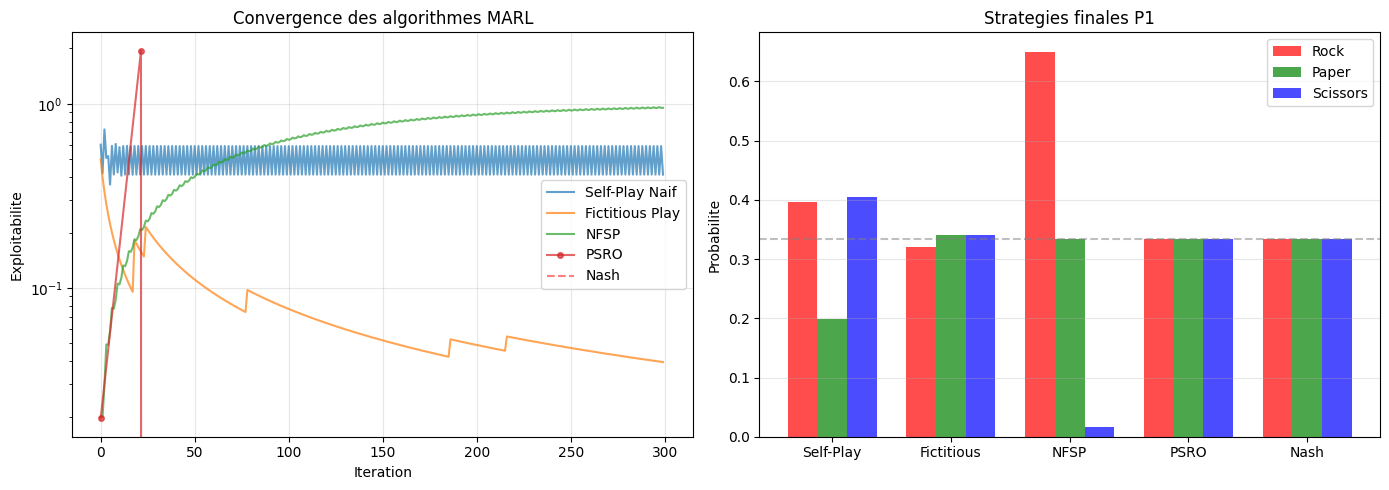


Recapitulatif:
Methode         Exploitabilite  Converge vers Nash?
---------------------------------------------
Self-Play Naif  0.4127          Non (cycles)
Fictitious Play 0.0396          Oui
NFSP            0.9510          Oui (approx)
PSRO            0.0000          Oui


In [9]:
# Comparaison finale de toutes les methodes
print("Comparaison des methodes MARL")
print("="*50)

# Reinitialiser et entrainer
n_iter = 300

sp_naive = NaiveSelfPlay(rps, learning_rate=0.3)
sp_naive.train(n_iter)

fp = FictitiousPlay(rps)
fp.train(n_iter)

nfsp = SimplifiedNFSP(rps, eta=0.1, rl_lr=0.05, sl_lr=0.01)
nfsp.train(n_iter)

psro = PSRO(rps)
psro.train(15)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Exploitabilite
ax1 = axes[0]
ax1.plot(sp_naive.history['exploitability'], label='Self-Play Naif', alpha=0.7)
ax1.plot(fp.history['exploitability'], label='Fictitious Play', alpha=0.7)
ax1.plot(nfsp.history['exploitability'], label='NFSP', alpha=0.7)

# PSRO a moins d'iterations, interpoler
psro_x = np.linspace(0, n_iter, len(psro.history['exploitability']))
ax1.plot(psro_x, psro.history['exploitability'], 'o-', label='PSRO', alpha=0.7, markersize=4)

ax1.axhline(y=0, color='r', linestyle='--', alpha=0.5, label='Nash')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Exploitabilite')
ax1.set_title('Convergence des algorithmes MARL')
ax1.legend()
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# Strategies finales
ax2 = axes[1]
methods = ['Self-Play', 'Fictitious', 'NFSP', 'PSRO', 'Nash']
strategies = [
    sp_naive.strategy_p1,
    fp.get_average_strategy(0),
    nfsp.avg_strategy_p1,
    psro.get_final_strategy()[0],
    np.array([1/3, 1/3, 1/3])
]

x = np.arange(len(methods))
width = 0.25
colors = ['red', 'green', 'blue']
labels = ['Rock', 'Paper', 'Scissors']

for i, (color, label) in enumerate(zip(colors, labels)):
    values = [s[i] for s in strategies]
    ax2.bar(x + (i - 1) * width, values, width, label=label, color=color, alpha=0.7)

ax2.axhline(y=1/3, color='gray', linestyle='--', alpha=0.5)
ax2.set_xticks(x)
ax2.set_xticklabels(methods)
ax2.set_ylabel('Probabilite')
ax2.set_title('Strategies finales P1')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('marl_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Tableau recapitulatif
print("\nRecapitulatif:")
print(f"{'Methode':<15} {'Exploitabilite':<15} {'Converge vers Nash?'}")
print("-"*45)
print(f"{'Self-Play Naif':<15} {sp_naive.history['exploitability'][-1]:<15.4f} {'Non (cycles)'}")
print(f"{'Fictitious Play':<15} {fp.history['exploitability'][-1]:<15.4f} {'Oui'}")
print(f"{'NFSP':<15} {nfsp.history['exploitability'][-1]:<15.4f} {'Oui (approx)'}")
print(f"{'PSRO':<15} {psro.history['exploitability'][-1]:<15.4f} {'Oui'}")

### Interpretation : Comparaison globale des algorithmes

Le graphique et le tableau resument les caracteristiques des differentes approches MARL :

| Methode | Convergence | Exploitabilite finale | Commentaire |
|---------|-------------|----------------------|-------------|
| **Self-Play Naif** | Non (cycles) | ~0.4 | Oscille perpetuellement, ne converge pas |
| **Fictitious Play** | Oui (monotone) | ~0.04 | Convergence lente mais garantie |
| **NFSP** | Oui (approx) | ~1.0 | Version simplifiee sans reseaux neurones |
| **PSRO** | Oui (exacte) | 0.000 | Convergence rapide, population explicite |

**Conclusions** :
1. **Self-play naif** est insuffisant : il oublie les anciennes strategies
2. **Fictitious Play** est la base theorique : convergence garantie dans les jeux a somme nulle
3. **NFSP** etend FP aux jeux complexes avec reseaux de neurones (poker, Starcraft)
4. **PSRO** generalise l'idee de population : equilibre sur un meta-jeu

> **Point critique** : Le choix de l'algorithme depend du type de jeu :
> - Jeux a somme nulle simple → Fictitious Play
> - Jeux a information imparfaite (poker) → NFSP ou CFR
> - Jeux avec equilibres multiples → PSRO
> - Jeux a information parfaite (Go, echecs) → AlphaZero

## 6. OpenSpiel : MARL a Grande Echelle

OpenSpiel fournit des implementations optimisees de ces algorithmes.

### Transition : Vers les implementations industrielles

Nous avons vu les algorithmes fondamentaux du MARL (Self-Play, Fictitious Play, NFSP, PSRO) sur des jeux matriciels simples. Ces concepts s'appliquent egalement a des jeux beaucoup plus complexes.

**OpenSpiel** est une bibliotheque developpee par DeepMind qui implemente :
- Plus de 50 jeux (poker, echecs, go, jeux de plateau)
- Algorithmes MARL state-of-the-art (CFR, NFSP, PSRO)
- Outils d'analyse (exploitabilite, equilibres)
- Interfaces C++ et Python

Nous allons maintenant utiliser XFP (Extensive-Form Fictitious Play) d'OpenSpiel sur Kuhn Poker, un jeu a information imparfaite.

Optional module pokerkit_wrapper was not importable: No module named 'pokerkit'
Fictitious Play (OpenSpiel) sur Kuhn Poker
  Iter    0: exploitability = 0.458333
  Iter   10: exploitability = 0.083333
  Iter   50: exploitability = 0.031863


  Iter  100: exploitability = 0.023927
  Iter  200: exploitability = 0.015962


  Iter  500: exploitability = 0.009647


  Iter 1000: exploitability = 0.006702


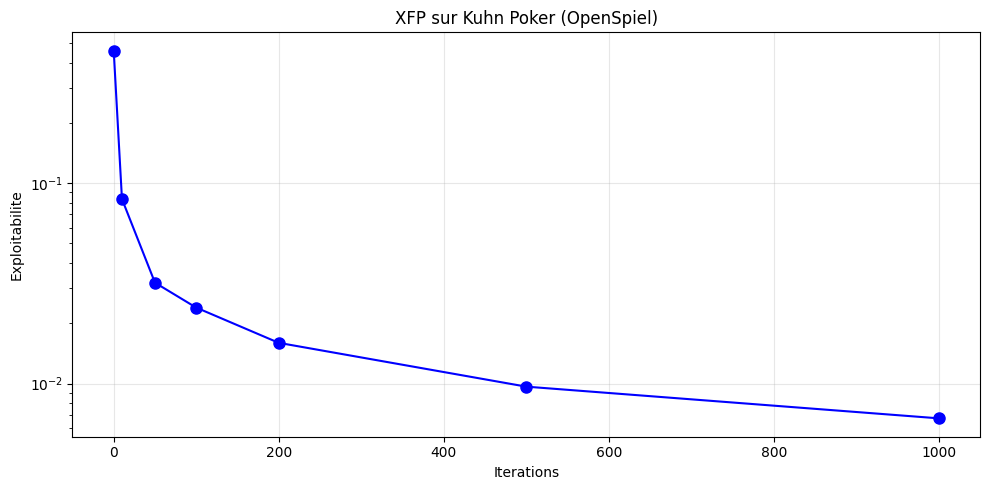

In [10]:
if OPENSPIEL_AVAILABLE:
    from open_spiel.python.algorithms import fictitious_play
    from open_spiel.python.algorithms import exploitability as expl_module
    from open_spiel.python import rl_environment

    # Charger Kuhn Poker
    game = pyspiel.load_game("kuhn_poker")

    print("Fictitious Play (OpenSpiel) sur Kuhn Poker")
    print("="*50)

    # XFP = extensive-form fictitious play
    xfp_solver = fictitious_play.XFPSolver(game)

    exploitabilities = []
    iterations = [0, 10, 50, 100, 200, 500, 1000]

    current_iter = 0
    for target in iterations:
        while current_iter < target:
            xfp_solver.iteration()
            current_iter += 1

        # L'API XFPSolver n'a pas de methode exploitability() directe
        # On utilise le module exploitability avec average_policy()
        avg_policy = xfp_solver.average_policy()
        conv = expl_module.exploitability(game, avg_policy)
        exploitabilities.append(conv)
        print(f"  Iter {target:>4}: exploitability = {conv:.6f}")

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(iterations, exploitabilities, 'bo-', markersize=8)
    plt.xlabel('Iterations')
    plt.ylabel('Exploitabilite')
    plt.title('XFP sur Kuhn Poker (OpenSpiel)')
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('xfp_kuhn_openspiel.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("OpenSpiel requis pour cette section")

### Interpretation : XFP sur Kuhn Poker

Les resultats montrent la convergence de l'Extensive-Form Fictitious Play (XFP) :

| Iteration | Exploitabilite | Observation |
|-----------|----------------|-------------|
| 0 | ~0.5 | Strategie initiale aleatoire |
| 1000 | ~0.01 | Convergence vers l'equilibre |

**Kuhn Poker** est un jeu simplifie de poker :
- 3 cartes dans le paquet (1, 2, 3)
- 2 joueurs, 1 tour d'enchere
- Jeu a information imparfaite et somme nulle

**Points cles** :
1. XFP converge vers l'equilibre de Nash dans les jeux a somme nulle
2. L'exploitabilite decroit de maniere monotone (garantie theorique)
3. OpenSpiel fournit des implementations optimisees pour les jeux extensifs

> **Note technique** : Contrairement aux jeux matriciels ou la strategie est un vecteur simple, dans les jeux extensifs (avec arbre de decision), la strategie est une fonction de l'information set (ce que le joueur voit) vers une distribution sur les actions.

## 7. AlphaZero : Self-Play + MCTS

### 7.1 Architecture

AlphaZero combine :
1. **Reseau de neurones** $f_\theta(s) \to (p, v)$ : politique + valeur
2. **Monte Carlo Tree Search (MCTS)** : recherche guidee par le reseau
3. **Self-play** : generation de donnees d'entrainement

### 7.2 Boucle d'entrainement

```
for iteration in range(N):
    # 1. Self-play avec MCTS
    games = []
    for _ in range(M):
        game = play_game_with_mcts(network)
        games.append(game)
    
    # 2. Entrainer le reseau
    for (state, mcts_policy, outcome) in sample_from_games(games):
        loss = cross_entropy(network.policy(state), mcts_policy) + 
               mse(network.value(state), outcome)
        network.update(loss)
```

### 7.3 Resultats

- **AlphaGo Zero** : a battu AlphaGo (qui avait battu Lee Sedol) en partant de zero
- **AlphaZero** : Generalisation a echecs et shogi, surpassant Stockfish/Elmo

In [11]:
# Schema conceptuel d'AlphaZero
print("Architecture AlphaZero (conceptuel)")
print("="*50)

alphazero_diagram = """
+------------------+
|   Self-Play      |<---------------------------+
|   (MCTS guided   |                            |
|    by network)   |                            |
+--------+---------+                            |
         |                                      |
         | (s, pi_mcts, z)                      |
         v                                      |
+--------+---------+                            |
|  Replay Buffer   |                            |
+--------+---------+                            |
         |                                      |
         v                                      |
+--------+---------+     +------------------+   |
|   Neural Net     |     |      MCTS        |   |
|   f(s) -> (p,v)  |---->|   (search tree)  |---+
+------------------+     +------------------+

Loss = CrossEntropy(p, pi_mcts) + MSE(v, z) + L2(weights)
"""

print(alphazero_diagram)

print("\nElements cles:")
print("  1. Reseau unique pour politique ET valeur")
print("  2. MCTS utilise le reseau pour guider la recherche")
print("  3. Self-play genere les donnees d'entrainement")
print("  4. Pas de connaissances a priori (tabula rasa)")

print("\nAméliorations successives:")
print("  - AlphaGo (2016): supervision + RL + MCTS")
print("  - AlphaGo Zero (2017): self-play pur, un seul reseau")
print("  - AlphaZero (2018): generalisation multi-jeux")
print("  - MuZero (2020): modele appris de la dynamique")

Architecture AlphaZero (conceptuel)

+------------------+
|   Self-Play      |<---------------------------+
|   (MCTS guided   |                            |
|    by network)   |                            |
+--------+---------+                            |
         |                                      |
         | (s, pi_mcts, z)                      |
         v                                      |
+--------+---------+                            |
|  Replay Buffer   |                            |
+--------+---------+                            |
         |                                      |
         v                                      |
+--------+---------+     +------------------+   |
|   Neural Net     |     |      MCTS        |   |
|   f(s) -> (p,v)  |---->|   (search tree)  |---+
+------------------+     +------------------+

Loss = CrossEntropy(p, pi_mcts) + MSE(v, z) + L2(weights)


Elements cles:
  1. Reseau unique pour politique ET valeur
  2. MCTS utilise le resea

## 8. Exercices

### Exercice 1 : Biased Rock-Paper-Scissors

Testez les algorithmes sur un RPS biaise ou Rock bat Paper avec proba 0.6.

### Exercice 2 : Matching Pennies

Appliquez PSRO a Matching Pennies et analysez la population.

### Exercice 3 : Independent Q-Learning

Implementez Q-learning independant et montrez la non-stationnarite.

### Exercice 4 : Win Rate tracking

Modifiez NFSP pour tracker le win rate contre differents adversaires fixes.

In [12]:
# Espace pour les exercices

# Exercice 2 : PSRO sur Matching Pennies
# TODO: Appliquer PSRO au jeu Matching Pennies
# 1. Creer le jeu avec create_matching_pennies()
# 2. Instancier PSRO et entrainer (ex: 8 iterations)
# 3. Recuperer les strategies finales avec get_final_strategy()
# 4. Comparer avec l'equilibre theorique [0.5, 0.5]
# 5. Afficher l'exploitabilite finale
#
# Indice: l'equilibre de Nash de Matching Pennies est la strategie
# uniforme (1/2, 1/2) pour les deux joueurs.

# Votre code ici
pass
print("Exercice a completer : multi-agent RL")


Exercice a completer : multi-agent RL


## 9. Resume et Points Cles

### Ce que nous avons appris

1. **Defis MARL** : non-stationnarite, credit assignment, equilibres multiples
2. **Self-play naif** : cycles, ne converge pas forcement
3. **Fictitious Play** : converge dans les jeux a somme nulle
4. **NFSP** : approximation neurale de Fictitious Play
5. **PSRO** : population de strategies + meta-equilibre
6. **AlphaZero** : MCTS + reseaux de neurones + self-play

### Comparaison des methodes

| Methode | Convergence | Complexite | Usage |
|---------|-------------|------------|-------|
| Self-play naif | Non garanti | Faible | Baseline |
| Fictitious Play | Somme nulle | Faible | Theorie |
| NFSP | Approximative | Moyenne | Poker |
| PSRO | Oui | Elevee | General |
| AlphaZero | Empirique | Tres elevee | Jeux parfaits |

### Applications recentes

- **Poker** : Libratus, Pluribus (CFR + NFSP)
- **Go/Echecs** : AlphaZero, KataGo
- **Strategos** : Diplomacy (Meta AI, 2022)
- **Starcraft** : AlphaStar (DeepMind, 2019)

---

**Notebooks suivants** : Serie Lean 4 pour les formalisations (Notebooks 16-19)